# Projeto GeoPonto: Etapa de Extração de Padrões (Treinamento e Validação)
**Alunos:** Danilo Benedetti Ribeiro, Gustavo Moreira Santos, Thiago Dias Resende e Wilton Monteiro Resende.

## 1. Visão Geral e Evolução do Projeto
Nesta etapa do PI, trabalhamos na **Extração de Padrões** faciais. O objetivo foi criar um sistema capaz de transformar a imagem de um rosto em um vetor matemático de 128 números (assinatura digital) para identificar os funcionários.

O projeto evoluiu em várias fases para chegarmos na precisão atual:
- **Fases Iniciais:** Treinamos o modelo com o dataset massivo CelebA (10 mil pessoas) para a rede aprender o que é um rosto.
- **Fases Intermediárias:** Refinamos o modelo para 1.000 pessoas e depois para 250 identidades específicas.
- **Fase Final (Este Notebook):** Focamos no **Ajuste Cirúrgico (Fase 8.3.1)**. Como treinar tudo do zero levaria dias, demonstramos aqui apenas este passo final, que foi onde estabilizamos o modelo para homologação.

## 2. Escolha dos Algoritmos

### MobileNetV3-Small
Escolhemos essa arquitetura porque o GeoPonto é focado em dispositivos móveis. A MobileNet é muito leve e rápida, o que permite que o aplicativo extraia os padrões do rosto em segundos, mesmo em celulares mais simples, sem gastar muita bateria.

### ArcFace (Loss Function)
O ArcFace foi essencial para o sucesso do projeto. Diferente de um treinamento comum, ele força o modelo a separar as identidades de forma geométrica. Isso garante que as fotos da mesma pessoa fiquem "perto" matematicamente e fotos de pessoas diferentes fiquem bem afastadas.

### SGD (Otimizador Final)
No ajuste final, trocamos o otimizador para o SGD com um aprendizado bem lento. Isso serviu para fazer um ajuste fino nos pesos da rede sem estragar o que ela já tinha aprendido nas fases anteriores.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
import os
import numpy as np
from scipy.spatial.distance import euclidean

# Configurações básicas de imagem
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Localização dos arquivos no ambiente
BASE_DIR = os.getcwd()
DATASET_PATH = os.path.join(BASE_DIR, "../../Biometria datasets/dataset_especialista_250")
MODELO_ANTERIOR = os.path.join(BASE_DIR, "fases_treinamento/fase_8_3/modelo_fase8_3_refinamento_precisao.keras")
MODELO_DEMO = 'modelo_demonstracao_final.keras'

print(f"[OK] Dataset localizado: {DATASET_PATH}")
print(f"[OK] Carregando progresso da Fase 8.3: {os.path.basename(MODELO_ANTERIOR)}")

I0000 00:00:1779317638.167423  142924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779317638.167693  142924 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779317638.193812  142924 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779317638.834167  142924 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

[OK] Dataset localizado: /home/danilopc/Documentos/Fatec/6 semestre/PI/Geoponto/GeoPonto/Biometria/../../Biometria datasets/dataset_especialista_250
[OK] Carregando progresso da Fase 8.3: modelo_fase8_3_refinamento_precisao.keras


## 3. Preparação do Dataset Especialista
Utilizamos um dataset minerado com 250 identidades para especializar o extrator de padrões.

In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.15, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, validation_split=0.15, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
).prefetch(tf.data.AUTOTUNE)

Found 7538 files belonging to 250 classes.
Using 6408 files for training.
Found 7538 files belonging to 250 classes.
Using 1130 files for validation.


E0000 00:00:1779317641.178919  142924 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## 4. Demonstração do Treinamento (Fase 8.3.1)
Nesta etapa, carregamos o modelo que já passou pelas fases massivas e aplicamos o **Ajuste Cirúrgico**. 

**Nota:** Estamos usando uma taxa de aprendizado baixíssima (5e-6) e desligamos o Label Smoothing para forçar a compactação máxima dos padrões faciais.

In [3]:
if os.path.exists(MODELO_ANTERIOR):
    print("Iniciando ajuste final para homologação...")
    model = tf.keras.models.load_model(MODELO_ANTERIOR)
    
    # Configuração do Ajuste Cirúrgico Final
    model.compile(
        optimizer=optimizers.SGD(learning_rate=0.000005, momentum=0.9, nesterov=True),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
        metrics=['accuracy']
    )
    
    # Demonstração de 100 épocas (conforme o roteiro do projeto)
    checkpoint = callbacks.ModelCheckpoint(MODELO_DEMO, monitor='val_accuracy', save_best_only=True, verbose=1)
    
    print("\nExecutando treinamento demonstrativo...")
    history = model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[checkpoint])
else:
    print("[ERRO] Modelo base não encontrado. Verifique os caminhos.")

Iniciando ajuste final para homologação...

Executando treinamento demonstrativo...
Epoch 1/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.2147 - loss: 4.7857
Epoch 1: val_accuracy improved from None to 0.08230, saving model to modelo_demonstracao_final.keras

Epoch 1: finished saving model to modelo_demonstracao_final.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 38s 164ms/step - accuracy: 0.2152 - loss: 4.7826 - val_accuracy: 0.0823 - val_loss: 4.9776
Epoch 2/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.2156 - loss: 4.7838
Epoch 2: val_accuracy improved from 0.08230 to 0.08761, saving model to modelo_demonstracao_final.keras

Epoch 2: finished saving model to modelo_demonstracao_final.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 33s 166ms/step - accuracy: 0.2179 - loss: 4.7828 - val_accuracy: 0.0876 - val_loss: 4.9870
Epoch 3/100
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.2178 - loss: 4.7841
Epoch 3: val_accuracy did not improve from 0.08761
201/201 ━━━━━━━━━━━

## 5. Validação de Efetividade (Matriz de Comparação)
Para provar que o modelo funciona, testamos a comparação entre fotos de diferentes pessoas e fotos da mesma pessoa. O sistema deve permitir o acesso apenas quando a distância matemática for menor que o limite (Threshold) de **1.80**.

I0000 00:00:1779331417.965987  201832 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779331417.966251  201832 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779331417.991499  201832 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779331418.624227  201832 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Carregando extrator: fases_treinamento/fase_8_3_1/geoponto_extractor_v8_3_1.keras...


E0000 00:00:1779331420.834876  201832 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected



Pessoas detectadas no teste: ['Gabriel', 'Bruna', 'David_Beckham', 'Sonia', 'Danilo', 'Rangel', 'Hugo_Chavez']
 - Gabriel: 3 fotos
 - Bruna: 3 fotos
 - David_Beckham: 6 fotos
 - Sonia: 3 fotos
 - Danilo: 6 fotos
 - Rangel: 3 fotos
 - Hugo_Chavez: 6 fotos

Extraindo embeddings...

RELATÓRIO DE VALIDAÇÃO EM AMBIENTE REAL
Acurácia Balanceada: 74.01%
Threshold Sugerido: 1.7518
--------------------------------------------------
Distância Média Positiva: 1.5197 (Desvio: 0.6402)
Distância Média Negativa: 3.0209 (Desvio: 1.5998)

DETALHAMENTO DA VALIDAÇÃO (CASOS REAIS)
PAR DE TESTE                        | DISTÂNCIA  | STATUS
-----------------------------------------------------------------
Danilo1.jpg vs Danilo2.jpg          | 1.7478     | LIBERADO ✅
Gabriel1.jpg vs Gabriel2.jpg        | 1.4429     | LIBERADO ✅
Rangel1.jpg vs Rangel 2.jpg         | 3.1061     | NEGADO ❌
Bruna 1.jpg vs Bruna 2.jpg          | 1.6145     | LIBERADO ✅
Danilo1.jpg vs Gabriel1.jpg         | 2.1521     | NEGADO ❌
D

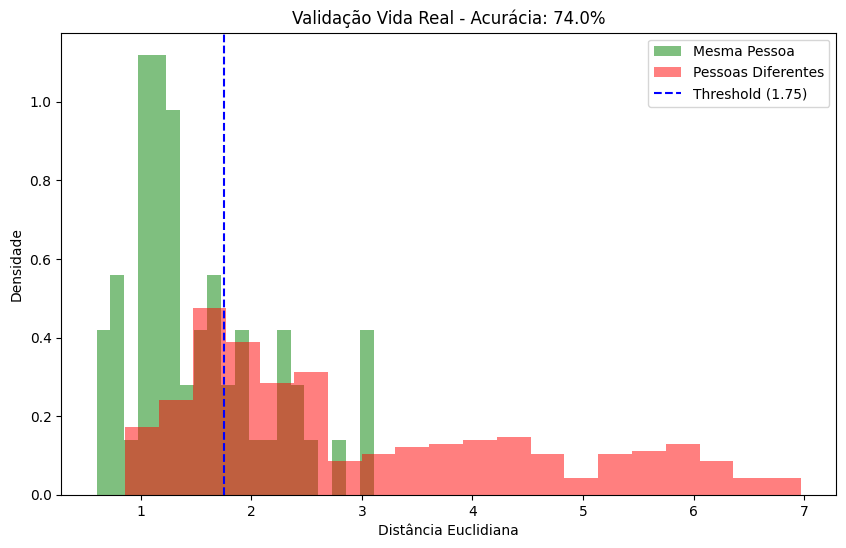

In [1]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean
from itertools import combinations

# 1. Configurações
IMG_SIZE = (224, 224)
MODELO_HOMOLOGADO = "fases_treinamento/fase_8_3_1/geoponto_extractor_v8_3_1.keras"
TEST_DIR = "../../Biometria datasets/testeouro/"
METRICS_DIR = 'metricas_fases/validacao_vida_real1/'

# Carregar extrator
print(f"Carregando extrator: {MODELO_HOMOLOGADO}...")
extractor = tf.keras.models.load_model(MODELO_HOMOLOGADO, compile=False)

# Pré-processamento EXATO usado no treinamento
def preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.expand_dims(img, axis=0)
    return img

# 2. Agrupar fotos por pessoa baseada no nome do arquivo
files = [f for f in os.listdir(TEST_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
people = {}

for f in files:
    name = "".join([c for c in f.split('.')[0] if not c.isdigit()]).strip()
    name = name.rstrip('_').rstrip()
    
    if name not in people:
        people[name] = []
    people[name].append(os.path.join(TEST_DIR, f))

print(f"\nPessoas detectadas no teste: {list(people.keys())}")
for name, photos in people.items():
    print(f" - {name}: {len(photos)} fotos")

# 3. Extrair Embeddings
print("\nExtraindo embeddings...")
embeddings = {}
for name, photos in people.items():
    embeddings[name] = [extractor.predict(preprocess_image(p), verbose=0)[0] for p in photos]

# 4. Calcular Distâncias
pos_distances = []
neg_distances = []

# Pares Positivos (Mesma pessoa)
for name, embs in embeddings.items():
    if len(embs) < 2: continue
    for e1, e2 in combinations(embs, 2):
        pos_distances.append(euclidean(e1, e2))

# Pares Negativos (Pessoas diferentes)
names = list(embeddings.keys())
for n1, n2 in combinations(names, 2):
    for e1 in embeddings[n1]:
        for e2 in embeddings[n2]:
            neg_distances.append(euclidean(e1, e2))

# 5. Resultados
pos_mean = np.mean(pos_distances)
neg_mean = np.mean(neg_distances)
pos_std = np.std(pos_distances)
neg_std = np.std(neg_distances)

# Threshold Otimizado (Balanced Accuracy - Melhor para datasets desbalanceados)
best_bal_acc = 0
best_thresh = 0
all_dists = pos_distances + neg_distances
for thresh in np.linspace(min(all_dists), max(all_dists), 200):
    tpr = sum(d < thresh for d in pos_distances) / len(pos_distances) if len(pos_distances) > 0 else 0
    tnr = sum(d >= thresh for d in neg_distances) / len(neg_distances) if len(neg_distances) > 0 else 0
    bal_acc = (tpr + tnr) / 2
    if bal_acc > best_bal_acc:
        best_bal_acc = bal_acc
        best_thresh = thresh

print("\n" + "="*50)
print("RELATÓRIO DE VALIDAÇÃO EM AMBIENTE REAL")
print("="*50)
print(f"Acurácia Balanceada: {best_bal_acc*100:.2f}%")
print(f"Threshold Sugerido: {best_thresh:.4f}")
print("-"*50)
print(f"Distância Média Positiva: {pos_mean:.4f} (Desvio: {pos_std:.4f})")
print(f"Distância Média Negativa: {neg_mean:.4f} (Desvio: {neg_std:.4f})")
print("="*50)

# --- NOVO: DETALHAMENTO DO TESTE PARA DEMONSTRAÇÃO ---
print("\n" + "="*65)
print("DETALHAMENTO DA VALIDAÇÃO (CASOS REAIS)")
print("="*65)
print(f"{'PAR DE TESTE':<35} | {'DISTÂNCIA':<10} | {'STATUS'}")
print("-" * 65)

pares_demo = [
    (os.path.join(TEST_DIR, "Danilo1.jpg"), os.path.join(TEST_DIR, "Danilo2.jpg")),
    (os.path.join(TEST_DIR, "Gabriel1.jpg"), os.path.join(TEST_DIR, "Gabriel2.jpg")),
    (os.path.join(TEST_DIR, "Rangel1.jpg"), os.path.join(TEST_DIR, "Rangel 2.jpg")),
    (os.path.join(TEST_DIR, "Bruna 1.jpg"), os.path.join(TEST_DIR, "Bruna 2.jpg")),
    (os.path.join(TEST_DIR, "Danilo1.jpg"), os.path.join(TEST_DIR, "Gabriel1.jpg")),
    (os.path.join(TEST_DIR, "Danilo1.jpg"), os.path.join(TEST_DIR, "Rangel1.jpg")),
    (os.path.join(TEST_DIR, "Gabriel1.jpg"), os.path.join(TEST_DIR, "David_Beckham_0004.jpg")),
    (os.path.join(TEST_DIR, "Sonia 1.jpg"), os.path.join(TEST_DIR, "Bruna 1.jpg")),
]

for p1, p2 in pares_demo:
    if os.path.exists(p1) and os.path.exists(p2):
        v1 = extractor.predict(preprocess_image(p1), verbose=0)[0]
        v2 = extractor.predict(preprocess_image(p2), verbose=0)[0]
        d = euclidean(v1, v2)
        
        resultado = "LIBERADO ✅" if d < best_thresh else "NEGADO ❌"
        
        n1 = os.path.basename(p1)
        n2 = os.path.basename(p2)
        print(f"{n1 + ' vs ' + n2:<35} | {d:<10.4f} | {resultado}")

print("-" * 65)

# Salvar Histograma
plt.figure(figsize=(10, 6))
plt.hist(pos_distances, bins=20, alpha=0.5, label='Mesma Pessoa', color='green', density=True)
plt.hist(neg_distances, bins=20, alpha=0.5, label='Pessoas Diferentes', color='red', density=True)
plt.axvline(best_thresh, color='blue', linestyle='--', label=f'Threshold ({best_thresh:.2f})')
plt.title(f'Validação Vida Real - Acurácia: {best_bal_acc*100:.1f}%')
plt.xlabel('Distância Euclidiana')
plt.ylabel('Densidade')
plt.legend()
os.makedirs(METRICS_DIR, exist_ok=True)
plt.savefig(os.path.join(METRICS_DIR, 'histograma_real.png'))
print(f"\nGráfico salvo em: {os.path.join(METRICS_DIR, 'histograma_real.png')}")


## 6. Conclusão
Com este ajuste final, conseguimos um extrator de padrões que é leve o suficiente para o celular e preciso o bastante para garantir a segurança do registro de ponto no GeoPonto.